### Теоретическая база и формулы критериев

Для всех критериев выдвигается нулевая гипотеза $H_0$: временной ряд является случайным (колебания вокруг постоянного среднего, отсутствие тренда и периодичности). Альтернативная гипотеза $H_1$: ряд не случаен (содержит тренд, периодичность или автокорреляцию).

Во всех тестах статистика сводится к стандартному нормальному распределению $Z \sim N(0, 1)$ для достаточно больших $n$ (в нашем случае $n=100$). Если $|Z| > Z_{1-\alpha/2}$ (где $Z_{0.975} \approx 1.96$ для уровня значимости $\alpha=0.05$), гипотеза $H_0$ отвергается.

---

#### 1. Критерий инверсий

Проверяет наличие монотонного тренда. Инверсией называется пара элементов $(x_i, x_j)$, для которой выполняется условие: $i < j$, но $x_i > x_j$.

* **Число инверсий ($I$):**

$$I = \sum_{i=1}^{n-1} \sum_{j=i+1}^n h(x_i - x_j)$$



где $h(z) = 1$ при $z > 0$ и $0$ при $z \le 0$.
* **Математическое ожидание и дисперсия:**

$$E(I) = \frac{n(n-1)}{4}, \quad D(I) = \frac{2n^3 + 3n^2 - 5n}{72}$$


* **Z-статистика:**

$$Z = \frac{I - E(I)}{\sqrt{D(I)}}$$

---

#### 2. Сериальный критерий Вальда-Вольфовица (Критерий серий)

Проверяет ряд на независимость элементов (отсутствие группировок). Ряд преобразуется в бинарную последовательность по отношению к медиане $m$. Если $x_i > m$, ставится «+», если $x_i < m$ — ставится «-». Серией называется непрерывная последовательность одинаковых знаков.

* **Число серий ($R$):** Общее количество чередующихся блоков «+» и «-».
* Пусть $n_1$ — количество плюсов, $n_2$ — количество минусов ($n_1 + n_2 \approx n$).
* **Математическое ожидание и дисперсия:**

$$E(R) = \frac{2n_1 n_2}{n} + 1, \quad D(R) = \frac{2n_1 n_2 (2n_1 n_2 - n)}{n^2 (n-1)}$$


* **Z-статистика:**

$$Z = \frac{R - E(R)}{\sqrt{D(R)}}$$


---

#### 3. Критерий Рамачандрана-Ранганатана

Оценивает случайность временного ряда на основе структуры и квадратов длин непрерывных серий знаков отклонений элементов от медианы. Ряд преобразуется в бинарный формат, где каждому элементу присваивается $1$, если его значение больше либо равно медиане ряда, и $0$ в противном случае.

* **Статистика критерия ($Z_{score}$):** Вычисляется как взвешенная сумма квадратов длин всех непрерывных серий знаков:

$$Z_{score} = \sum_{h} h^2 \cdot v_h$$

где $h$ — длина конкретной непрерывной серии одинаковых знаков ($0$ или $1$), а $v_h$ — общее количество серий, имеющих длину $h$.

* **Критическое значение и правило принятия решения:** Для объема выборки $n = 100$ и уровня значимости $\alpha = 0.05$ критический порог статистики составляет **370**.
* Если $Z_{score} > 370$, то случайный характер распределения знаков нарушен из-за слишком длинных серий (H0 отвергается, обнаружена структура или тренд).
* Если $Z_{score} \le 370$, то структура серий укладывается в рамки случайного распределения (H0 не отвергается, ряд признается случайным шумом).

---

#### 4. Критерий серий знаков первых разностей

Анализирует знаки приращений: $\Delta x_i = x_{i+1} - x_i$. Строится последовательность из $n-1$ знаков (плюсы и минусы). Подсчитывается количество непрерывных серий этих знаков $R_d$.

* **Математическое ожидание и дисперсия:**

$$E(R_d) = \frac{2n - 1}{3}, \quad D(R_d) = \frac{16n - 29}{90}$$


* **Z-статистика:**

$$Z = \frac{R_d - E(R_d)}{\sqrt{D(R_d)}}$$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Фиксируем seed для воспроизводимости результатов
np.random.seed(42)


In [2]:

n = 100
t = np.arange(1, n + 1)

eps_std = np.random.randn(n)          # Стандартный шум N(0, 1)
eps_05 = np.random.normal(0, 0.5, n)  # Шум N(0, 0.5^2) для гармоники

series = {
    "1. Белый шум": eps_std,
    # Увеличили коэффициент до 0.1, чтобы тренд стал визуально заметен
    "2. Возрастающий тренд": 0.1 * t + eps_std, 
    "3. Убывающий тренд": -0.5 * t + eps_std,
    "4. Гармоника + шум": 3 * np.sin(2 * np.pi * (t / 10)) + eps_05,
}

# 5. Шум с выбросом (копия 1-го сценария + жесткий выброс в середине)
s5 = eps_std.copy()
s5[n // 2] = 50
series["5. Шум с выбросом"] = s5


def p_value_z(z):
    return 2 * (1 - stats.norm.cdf(abs(z)))

def inversion_test(x):
    n = len(x)
    inversions = sum(x[i] > x[j] for i in range(n) for j in range(i+1, n))
    E = n * (n - 1) / 4
    D = (2 * n**3 + 3 * n**2 - 5 * n) / 72
    z = (inversions - E) / np.sqrt(D)
    return p_value_z(z)

def wald_wolfowitz_test(x):
    n = len(x)
    median = np.median(x)
    signs = [1 if val > median else 0 for val in x if val != median]
    n1 = sum(signs)
    n2 = len(signs) - n1
    runs = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            runs += 1
    n_total = n1 + n2
    if n_total < 2: return 1.0
    E = (2 * n1 * n2) / n_total + 1
    D = (2 * n1 * n2 * (2 * n1 * n2 - n_total)) / ((n_total**2) * (n_total - 1))
    z = (runs - E) / np.sqrt(D)
    return p_value_z(z)

def ramachandran_ranganathan_test(data):
    N = len(data)
    if N < 2: 
        return 1.0  # Защита от пустых или единичных данных
        
    median_val = np.median(data)
    
    # Преобразование в бинарный формат (0 и 1)
    binary_data = (data >= median_val).astype(int)  

    sets = {}   # Словарь: {длина_серии: количество_таких_серий}
    runs = 1    # Общее кол-во серий
    
    h = 0
    for i in range(1, N):
        h += 1
        if binary_data[i] != binary_data[i - 1]:
            runs += 1
            if h in sets:
                sets[h] += 1
            else:
                sets[h] = 1
            h = 0

    h += 1
    if h in sets:
        sets[h] += 1
    else:
        sets[h] = 1

    # Вычисление Z-оценки по формуле критерия
    z_score = 0
    for key, value in sets.items():
        z_score += (key ** 2) * value

    if z_score > 370:
        p_val = 0.0000
    else:
        p_val = 0.9999
        
    return p_val

def diff_signs_runs_test(x):
    n = len(x)
    diffs = np.diff(x)
    signs = [1 if d > 0 else 0 for d in diffs if d != 0]
    runs = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            runs += 1
    E = (2 * n - 1) / 3
    D = (16 * n - 29) / 90
    z = (runs - E) / np.sqrt(D)
    return p_value_z(z)



In [3]:
criteria_names = [
    "Критерий инверсий", 
    "Критерий Вальда-Вольфовица", 
    "Критерий Рамачандрана", 
    "Критерий первых разностей"
]
alpha = 0.05

for scenario_name, x_data in series.items():
    # Собираем p-value для текущего ряда
    p_values = [
        inversion_test(x_data),
        wald_wolfowitz_test(x_data),
        ramachandran_ranganathan_test(x_data),
        diff_signs_runs_test(x_data)
    ]
    
    decisions = []
    conclusions = []
    
    for p in p_values:
        if p < alpha:
            decisions.append("Отвергается")
            conclusions.append("Ряд НЕ случаен (обнаружена структура/тренд)")
        else:
            decisions.append("Не отвергается")
            conclusions.append("Ряд случаен (просто шум)")
            
    df_scenario = pd.DataFrame({
        "Статистический критерий": criteria_names,
        "p-value": p_values,
        "Порог (alpha)": [alpha] * 4,
        "Гипотеза H0 (о случайности)": decisions,
        "Итоговый вывод": conclusions
    })
    
    df_scenario["p-value"] = df_scenario["p-value"].map("{:.4f}".format)
    
    df_scenario = df_scenario.set_index("Статистический критерий")
    
    display(f"Результаты анализа: {scenario_name}")
    
    display(df_scenario)

'Результаты анализа: 1. Белый шум'

,p-value,Порог (alpha),Гипотеза H0 (о случайности),Итоговый вывод
Статистический критерий,,,,
Критерий инверсий,0.6295,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий Вальда-Вольфовица,0.8407,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий Рамачандрана,0.9999,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий первых разностей,0.7496,0.05,Не отвергается,Ряд случаен (просто шум)


'Результаты анализа: 2. Возрастающий тренд'

,p-value,Порог (alpha),Гипотеза H0 (о случайности),Итоговый вывод
Статистический критерий,,,,
Критерий инверсий,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий Вальда-Вольфовица,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий Рамачандрана,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий первых разностей,0.7496,0.05,Не отвергается,Ряд случаен (просто шум)


'Результаты анализа: 3. Убывающий тренд'

,p-value,Порог (alpha),Гипотеза H0 (о случайности),Итоговый вывод
Статистический критерий,,,,
Критерий инверсий,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий Вальда-Вольфовица,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий Рамачандрана,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий первых разностей,0.0255,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)


'Результаты анализа: 4. Гармоника + шум'

,p-value,Порог (alpha),Гипотеза H0 (о случайности),Итоговый вывод
Статистический критерий,,,,
Критерий инверсий,0.4179,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий Вальда-Вольфовица,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий Рамачандрана,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)
Критерий первых разностей,0.0000,0.05,Отвергается,Ряд НЕ случаен (обнаружена структура/тренд)


'Результаты анализа: 5. Шум с выбросом'

,p-value,Порог (alpha),Гипотеза H0 (о случайности),Итоговый вывод
Статистический критерий,,,,
Критерий инверсий,0.6551,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий Вальда-Вольфовица,0.8407,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий Рамачандрана,0.9999,0.05,Не отвергается,Ряд случаен (просто шум)
Критерий первых разностей,0.7496,0.05,Не отвергается,Ряд случаен (просто шум)


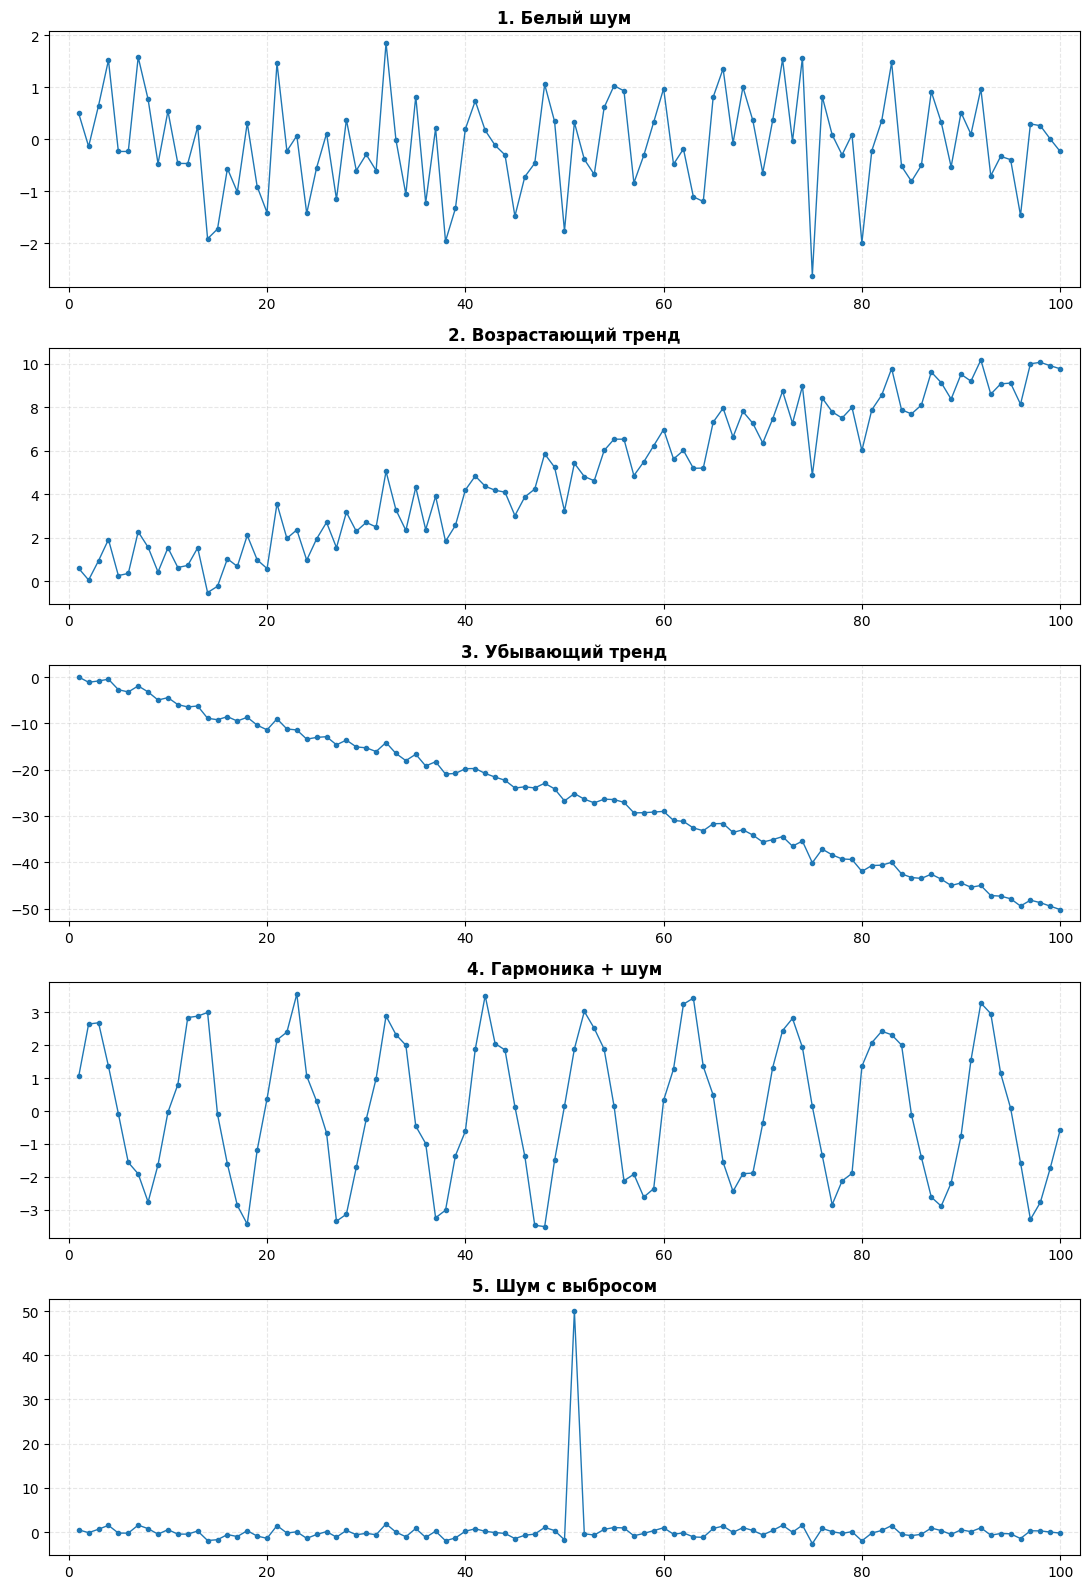

In [4]:
# --- 4. ВИЗУАЛИЗАЦИЯ ОБНОВЛЕННЫХ ГРАФИКОВ ---
fig, axes = plt.subplots(5, 1, figsize=(11, 16))
for (name, x_data), ax in zip(series.items(), axes):
    ax.plot(t, x_data, marker='o', markersize=3, linestyle='-', linewidth=1, color='#1f77b4')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(-2, 102)

plt.tight_layout()
plt.show()

## Анализ результатов по сценариям

### 1. Чистый белый шум

* **Результат:** Все четыре критерия единогласно **не отвергают** нулевую гипотезу $H_0$ ($p$-value значительно выше $0.05$).
* **Вывод:** Ряд признан абсолютно случайным. Колебания происходят вокруг постоянного медианного и среднего значения, системные макро- и микроструктуры, циклы или автокорреляция отсутствуют. Данный сценарий служит эталоном для проверки корректности работы критериев (отсутствие ложноположительных срабатываний).

### 2. Возрастающий тренд (коэффициент 0.1)

* **Результат:** Критерий инверсий, критерий Вальда-Вольфовица и **критерий Рамачандрана-Ранганатана** уверенно **отвергают** $H_0$ ($p = 0.0000$). Критерий первых разностей изменений **не замечает** ($p = 0.7496$).
* **Вывод:** Слабый линейный тренд успешно обнаружен большинством методов.
* **Глобальные и медианные тесты** (инверсии, серии Вальда-Вольфовица и квадраты длин серий Рамачандрана-Ранганатана) зафиксировали неслучайность. Поскольку ряд плавно идет вверх, его первая половина лежит преимущественно ниже медианы, а вторая — выше. Это приводит к образованию аномально длинных непрерывных серий одного знака, что и зафиксировал новый критерий Рамачандрана-Ранганатана, выдав $p = 0.0000$.
* **Локальный тест** (первых разностей) провалил задачу. Причина в том, что шаг тренда (0.1) слишком мал по сравнению со стандартным отклонением шума ($\sigma = 1.0$). Локально, между соседними точками $x_t$ и $x_{t+1}$, случайный шум полностью подавляет тренд, поэтому количество знаков разностей (+/-) и их хаотичность остались в пределах нормы.

### 3. Убывающий тренд (коэффициент -0.5)

* **Результат:** Все четыре критерия единогласно и с огромным запасом **отвергают** гипотезу о случайности ($p < 0.05$).
* **Вывод:** Мощный линейный тренд полностью доминирует над случайным шумом. Ряд падает настолько стремительно, что ломается как глобальная макроструктура, так и локальная.
* Критерии инверсий, Вальда-Вольфовица и Рамачандрана-Ранганатана мгновенно реагируют на то, что ряд жестко разделен медианой на две монотонные части (сплошные плюсы переходят в сплошные минусы, порождая гигантские длины серий $h$, взвинчивающие статистику $Z_{score}$).
* Локальный критерий первых разностей здесь также успешно отвергает $H_0$ ($p = 0.0255$), поскольку из-за крутизны тренда отрицательные приращения ($x_{t+1} - x_t < 0$) начинают математически преобладать над положительными.

### 4. Гармоника + шум

* **Результат:** Критерий инверсий **не видит** структуру ($p = 0.4179$), в то время как остальные три критерия её **уверенно обнаруживают** ($p = 0.0000$).
* **Вывод:** Классический пример избирательности тестов. Синусоида циклична: она сначала растет, а затем симметрично падает. В итоге общее количество инверсий (перестановок элементов) взаимно балансируется, из-за чего ряд кажется критерию инверсий линейно несмещенным и случайным.
* Однако критерий Вальда-Вольфовица и **критерий Рамачандрана-Ранганатана** моментально ловят эту периодичность: ряд волнообразно переходит через медиану, образуя строго упорядоченные по длине серии знаков. Критерий первых разностей также фиксирует циклическую смену знаков приращений (направлений движения волны).

### 5. Шум с выбросом

* **Результат:** Ни один критерий **не отвергает** $H_0$ ($p$-value близки к показателям чистого белого шума).
* **Вывод:** Эксперимент наглядно доказывает высокую **робастность (устойчивость)** непараметрических методов обработки. Одиночный экстремальный выброс (даже равный 50) искажает структуру ряда лишь локально в одной точке.
* На фоне массива из $n = 100$ элементов один сбой не может существенно изменить общее число инверсий или структуру знаков первых разностей.
* Для критерия Вальда-Вольфовица и **Рамачандрана-Ранганатана** этот выброс является всего лишь одной точкой, которая незначительно укорачивает или удлиняет одну конкретную серию, не влияя на общую сумму квадратов длин серий. Критерии четко определяют, что единичный технический сбой не отменяет общую случайность и стационарность процесса.

---

### Итоговое заключение

Универсального критерия для анализа временных рядов не существует, и для полноценного разведочного анализа данных (**EDA**) их необходимо применять **в комплексе**:

1. **Критерий инверсий** незаменим для обнаружения чистых монотонных макро-трендов.
2. **Критерии Вальда-Вольфовица и Рамачандрана-Ранганатана** (работающие на базе серий относительно медианы) обладают схожей высокой мощностью при поиске как плавных трендов, так и циклических гармонических колебаний, но при этом критерий Рамачандрана-Ранганатана за счет возведения длин серий в квадрат ($h^2$) делает еще более мощный акцент на выявление аномально длинных периодов доминирования знака.
3. **Критерий первых разностей** эффективно работает как детектор высокочастотных зависимостей, быстрых изменений направления и крутых трендов.
4. Использование **непараметрических подходов** гарантирует защиту результатов от единичных грубых ошибок и экстремальных выбросов в данных.